In [1]:
import os
if os.path.basename(os.getcwd()) == 'Demonstrations':
    os.chdir('..')

<div style="background-color: #3eb911; color: white; padding: 30px; border-radius: 0px;">
<h1 style="margin: 0;  color: #004f8f">Poisson problem solved via Finite Element Method (FEM)</h3>
</div>

Imports:

In [2]:
import numpy as np
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

from Utilities.fem_poisson import *
from Utilities.Mesh_processing import *

---
Mesh generation (Hollow Disk)

In [3]:
n_segments = 23
r_inner, r_outer = 0.5, 1.0

p0 = []
for r in [r_outer, r_inner]:
    for i in range(n_segments):
        theta = 2 * np.pi * i / n_segments
        p0.append([r * np.cos(theta), r * np.sin(theta)])
p0 = np.array(p0, dtype='d')

e0 = []
for i in range(n_segments):
    e0.append([i, (i + 1) % n_segments, 1])
for i in range(n_segments):
    e0.append([i + n_segments, ((i + 1) % n_segments) + n_segments, 2]) 
for i in range(n_segments):
    e0.append([i, i + n_segments, 0]) 
e0 = np.array(e0, dtype='i')

t0 = []
for i in range(n_segments):
    p_out_1 = i
    p_out_2 = (i + 1) % n_segments
    p_in_1  = i + n_segments
    p_in_2  = ((i + 1) % n_segments) + n_segments
    
    e_out    = i
    e_in     = i + n_segments
    e_rad_1  = i + 2 * n_segments
    e_rad_2  = ((i + 1) % n_segments) + 2 * n_segments

diag_start_idx = len(e0)
e_diags = []
for i in range(n_segments):
    e_diags.append([i, ((i + 1) % n_segments) + n_segments, 0])
e0 = np.vstack([e0, np.array(e_diags)])

t0 = []
for i in range(n_segments):
    p_out_1, p_out_2 = i, (i + 1) % n_segments
    p_in_1,  p_in_2  = i + n_segments, ((i + 1) % n_segments) + n_segments
    
    e_out, e_in = i, i + n_segments
    e_rad_1, e_rad_2 = i + 2*n_segments, ((i+1)%n_segments) + 2*n_segments
    e_diag = i + 3*n_segments
    
    t0.append([p_out_1, p_out_2, p_in_2, e_out, e_rad_2, e_diag, 0])
    
    t0.append([p_out_1, p_in_2, p_in_1, e_diag, e_in, e_rad_1, 0])

t0 = np.array(t0, dtype='i')

In [4]:
p, e, t = refine_n_times(p0, e0, t0, number_of_refinements=3) 

# The source function
def source_function(x, y, subdomain):
    return np.sin(np.pi * x) * np.exp(y)

f_values = evalOnTrigs(p, t, source_function)

# System
A = assembleStiffness(p, t, coef_a=1.0)     # Standard Poisson
f = assembleLoad(p, t, coef_f=f_values)     # Varying source term

In [5]:
mesh_df(p, e, t, first_n_entries=13)

p is of shape: (1656, 2)
e is of shape: (4600, 3)
t is of shape: (2944, 7)


In [6]:
# Boundary nodes (e[:, 2] > 0 marks the boundary)
boundary_nodes = np.unique(e[e[:, 2] > 0, 0:2])

# Apply Dirichlet BC (u = 0)
# .tolil() - efficient row modification
A_bc = A.tolil()
f_bc = f.copy()

for node in boundary_nodes:
    A_bc[node, :] = 0      
    A_bc[node, node] = 1   
    f_bc[node] = 0         

In [7]:
u = spla.spsolve(A_bc.tocsc(), f_bc)

Plotting the solution for visual analysis:

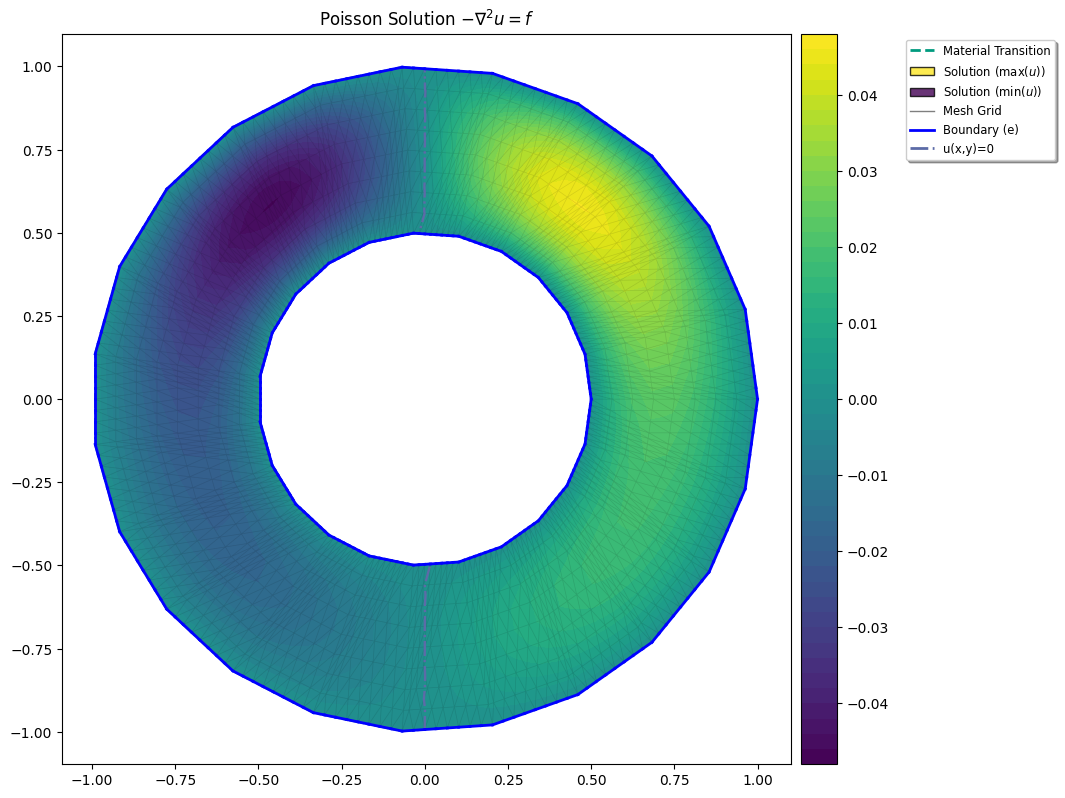

In [8]:
Plot_the_solution(u, p, t, e)

---
<br>
<div style="background-color: #c4ddff; color: white; padding: 10px; border-radius: 0px;">
<h1 style="margin: 0;  color: #004f8f">Reduced Order Modeling (ROM)</h3>
</div>

In [9]:
def snapshot_generator(p, e, t, operator: callable, ):
    """
    Generates snapshots for different parameters and outputs a snapshot matrix **S**.
    """    
    snapshots = []
    S = np.column_stack(snapshots)
    
    #TODO

    return S

In [10]:
# Parameter range
mu_values = np.linspace(1.0, 10.0, 10)
snapshots = []

# Stiffness Matrix does not change with mu
A_raw = assembleStiffness(p, t, coef_a=1.0)
boundary_nodes = np.unique(e[e[:, 2] > 0, 0:2])


A_bc = A_raw.tolil()

# BC (u=0)
for node in boundary_nodes:
    A_bc[node, :] = 0
    A_bc[:, node] = 0
    A_bc[node, node] = 1

# LU factorization
A_csc = A_bc.tocsc()
solve_lu = spla.splu(A_csc)

# Snapshot Generation
for mu in mu_values:
    for m2 in mu_values:
        for t1, t2 in ( (np.sin, np.sin), (np.sin, np.cos), (np.cos, np.sin), (np.cos, np.cos) ):
            # Sources for mus
            def parameterized_f(x, y, subdomain):
                return  t1(np.pi * mu * x) * t2(np.pi * m2 * y)
            # def parameterized_f(x,y, subdomain):
            #     return np.random.rand(1)[0]        
            
            f_vals = evalOnTrigs(p, t, parameterized_f)
            b = assembleLoad(p, t, coef_f=f_vals)              
            b_bc = b.copy()
            b_bc[boundary_nodes] = 0
            u_mu = solve_lu.solve(b_bc) 
            snapshots.append(u_mu)

# Snapshot Matrix S 
S = np.column_stack(snapshots)

print(f"Snapshot matrix shape: {S.shape}")

Snapshot matrix shape: (1656, 400)


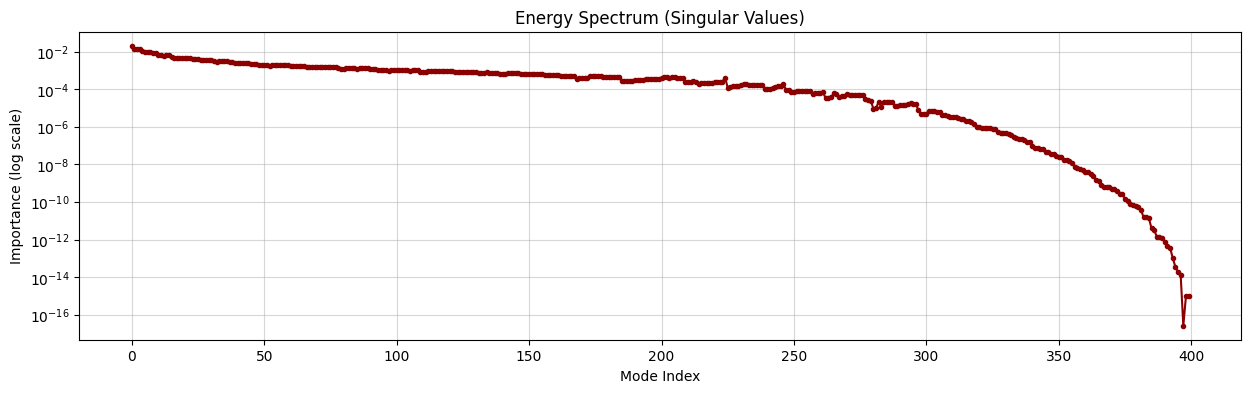

k = 234


In [11]:
# VT has the proper othogonal basis
#U, Sigma, VT = np.linalg.svd(S.T @ A_bc @ S, full_matrices=False)
[Sigma,U]=np.linalg.eig(S.T @ A_bc @ S)
U = U.real # Matrix is symmetric, so true eigenvalues are real valued

# Sigma plot
plt.figure(figsize=(15, 4))
plt.semilogy(Sigma, 'o-', markersize=3, color='darkred')
plt.title("Energy Spectrum (Singular Values)")
plt.xlabel("Mode Index")
plt.ylabel("Importance (log scale)")
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

# most important sigmas
cumulative_energy = np.cumsum(Sigma) / np.sum(Sigma)
k = np.argmax(cumulative_energy > 0.99) + 1
print(f"k = {k}")
#print(U.shape, VT.shape, S.shape, A_bc.shape)

In [12]:

V_RB = S @ U[:, :k] 
print(V_RB.shape)
# --- OFFLINE PHASE ---
A_reduced = V_RB.T @ (A_bc @ V_RB)


# --- ONLINE PHASE ---
mu_new = 5.59

def parameterized_f(x, y, subdomain):
    return np.sin(np.pi * x * mu_new) * np.exp(np.pi)


f_vals = evalOnTrigs(p, t, parameterized_f)
f_raw = assembleLoad(p, t, f_vals)

f_fom = f_raw.copy()
f_fom[boundary_nodes] = 0 

# Project to reduced space
f_reduced = V_RB.T @ f_fom

# Solve the reduced system (k x k)
alpha = np.linalg.solve(A_reduced, f_reduced)

# Reconstruct
u_approx = V_RB @ alpha

(1656, 234)


Selected modes plot:

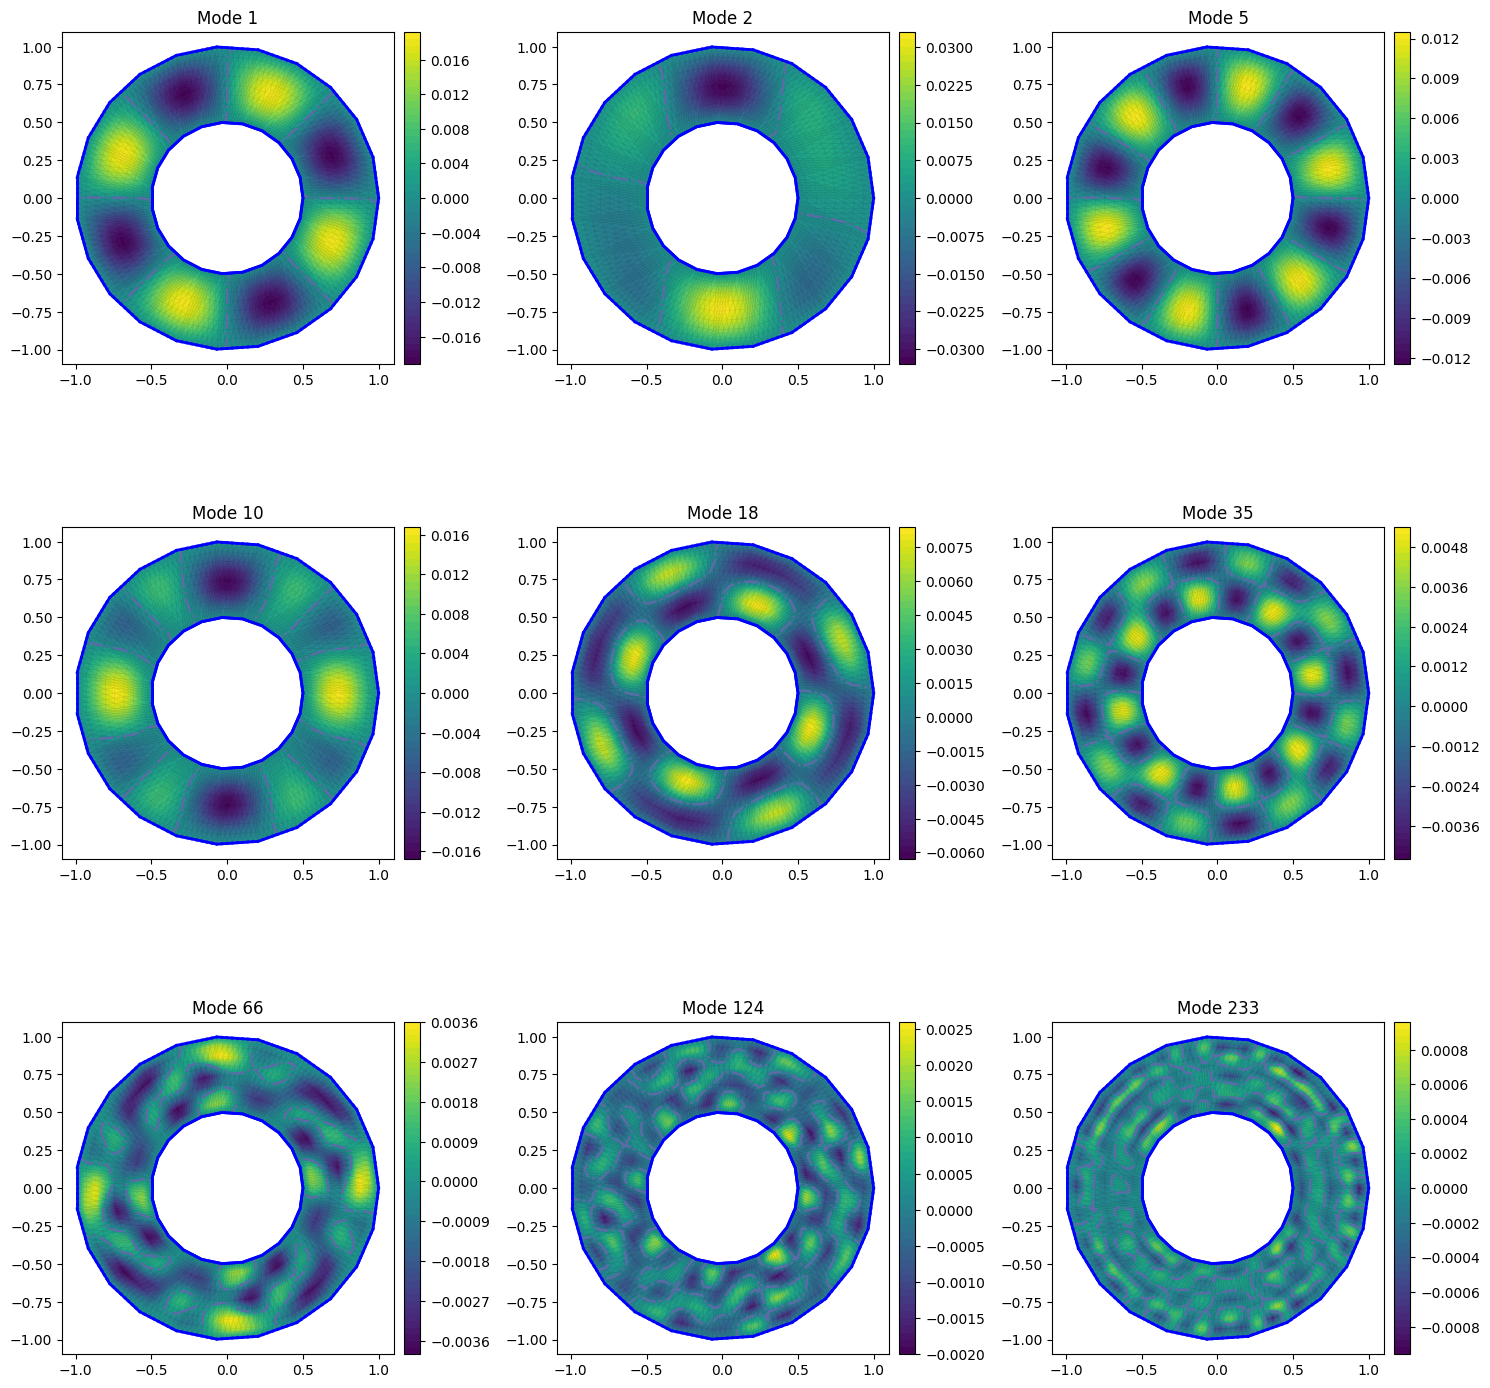

In [13]:
Plot_Modes(V_RB, k, p, t, e,
           nrows=3, ncols=3, stepping_factor=1.5)

Comparison to the true solution:

Relative Error: 7.09e-02
True solution between: -9.64e-02 and 9.74e-02
Approx solution between: -9.83e-02 and 9.91e-02


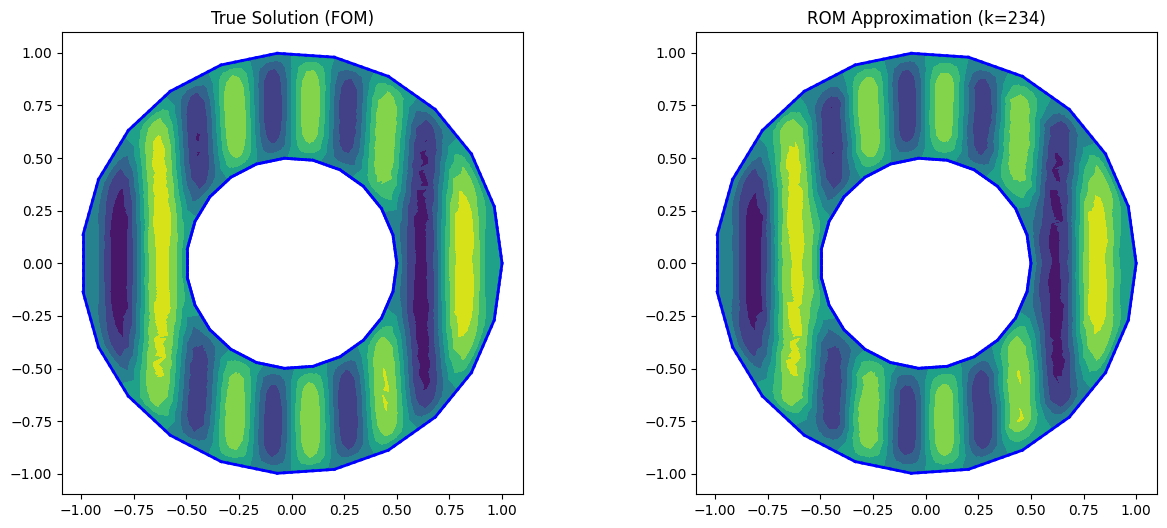

In [14]:
u_true = spla.spsolve(A_bc.tocsc(), f_fom)
ROM_comparison(u_true, u_approx, k, p, e, t)

#TODO SOMETHING IS WRONG WITH THE ERROR PLOT

In [ ]:
error_seq = []
k_seq = []

def rom_for_varying_k(A_bc, k, mu_new:float = 4.5):

    V_RB = S @ U[:, :k] 

    # --- OFFLINE PHASE ---
    A_reduced = V_RB.T @ (A_bc @ V_RB)

    # --- ONLINE PHASE ---
    def parameterized_f(x, y, subdomain):
        return np.sin(np.pi * x * mu_new) * np.exp(np.pi)

    f_vals = evalOnTrigs(p, t, parameterized_f)
    f_raw = assembleLoad(p, t, f_vals)
    f_fom = f_raw.copy()
    f_fom[boundary_nodes] = 0 
    f_reduced = V_RB.T @ f_fom

    alpha = np.linalg.solve(A_reduced, f_reduced)
    u_approx = V_RB @ alpha
    
    return u_approx

for k in range(1, Sigma.shape[0]+1):        
    u_approx = rom_for_varying_k(A_bc, k)
    # Error
    error = 1/2 * np.linalg.norm(u_true - u_approx) / np.linalg.norm(u_true)
    error_seq.append(error)
    k_seq.append(k+1)


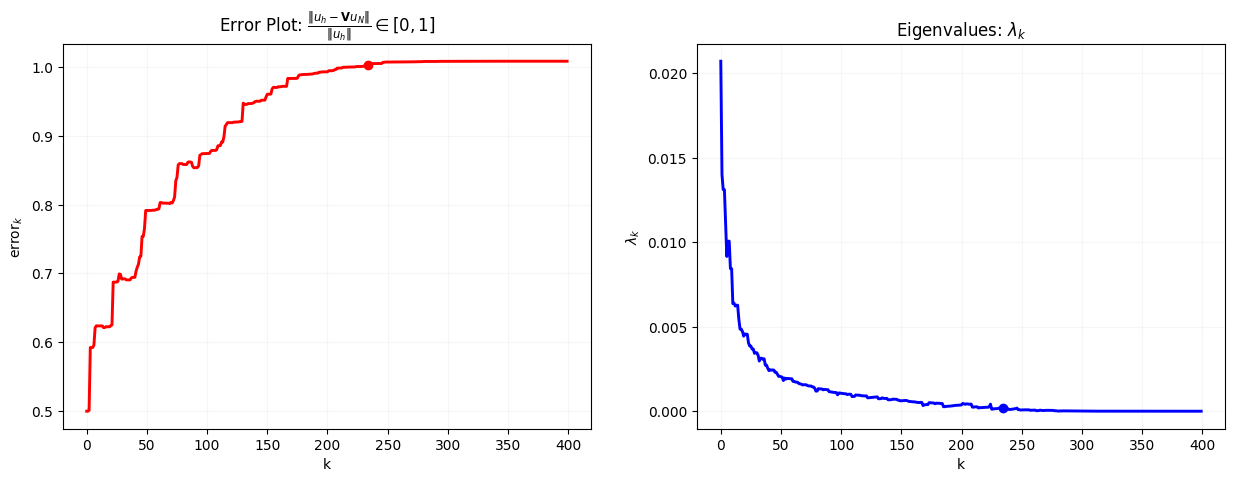

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))
ax[0].plot(error_seq, linewidth = 2.1, color = 'r')
ax[1].plot(Sigma, linewidth = 2.1, color = 'b')
ax[0].set_title(r'Error Plot: $\frac{\|u_h - \mathbf{V}u_N\|}{\|u_h\|} \in [0,1]$')
ax[1].set_title(r'Eigenvalues: $\lambda_k$')
ax[0].set_xlabel('k')
ax[1].set_xlabel('k')
ax[0].set_ylabel(r'error$_k$')
ax[1].set_ylabel(r'$\lambda_k$')

cumulative_energy = np.cumsum(Sigma) / np.sum(Sigma)
k = np.argmax(cumulative_energy > 0.99) + 1
u_approx = rom_for_varying_k(A_bc, k)
error = 1/2 * np.linalg.norm(u_true - u_approx) / np.linalg.norm(u_true)

ax[0].scatter(x = k, y = error, c = 'r', zorder = 3)
ax[1].scatter(x = k, y = Sigma[k], c = 'b', zorder = 3)

for i in [0,1]:
    ax[i].grid(True, alpha=0.1)

plt.show()